# Deep Learning Classification Project with AWS SageMaker Deployment

### Introduction

This notebook walks you through building, training, and deploying a deep learning image classification model using PyTorch and AWS SageMaker.

**Steps Forward:**
- Data preparation and preprocessing for image classification
- Building a Convolutional Neural Network (CNN) from scratch
- Training with best practices (learning rate scheduling, checkpointing)
- Packaging models for SageMaker deployment
- Deploying to a real-time inference endpoint
- Testing and monitoring your deployed model
- Cost management on AWS Free Tier

## 1. Problem Statement

We will build an image classification system that recognizes handwritten digits (0-9) from the MNIST dataset. This classic machine learning problem demonstrates production-ready deployment practices using AWS Sagemaker.

## 2. Environment Setup

### 2.1 Verify AWS CLI Configuration

In [1]:
# Check AWS CLI version
!aws --version

aws-cli/2.33.13 Python/3.13.11 Darwin/25.2.0 exe/arm64


In [2]:
# Verify credentials are configured
!aws sts get-caller-identity

{
    "UserId": "AIDA3PR6ZSXCBYUEFVW25",
    "Account": "789331940804",
    "Arn": "arn:aws:iam::789331940804:user/sagemaker-example"
}


### 2.2 Install Dependencies with Exact Versions

In [3]:
# Install all required packages with exact versions
!pip install -r requirements.txt

In [4]:
# Verify installation
import torch
import torchvision
import numpy as np
import boto3
import sagemaker

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /Users/orbinsunny/Library/Application Support/sagemaker/config.yaml


### 2.3 Import All Required Libraries

In [5]:
# Core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader

# Torchvision
from torchvision import datasets, transforms

# AWS
import boto3
import sagemaker
from sagemaker.pytorch import PyTorchModel

# Data processing
import numpy as np
import pandas as pd
from PIL import Image

# Utilities
import os
import json
import pickle
import time
import tarfile
import shutil
from datetime import datetime
from tqdm.notebook import tqdm

# Visualization
import matplotlib.pyplot as plt
%matplotlib inline

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## Chapter 3: Data Preparation

### 3.1 Understanding the MNIST Dataset

| Property | Value |
|----------|-------|
| Total Images | 70,000 |
| Training Set | 60,000 images |
| Test Set | 10,000 images |
| Image Size | 28 x 28 pixels |
| Color Channels | 1 (grayscale) |
| Classes | 10 (digits 0-9) |
| Pixel Range | 0-255 |

### 3.2 Configuration

In [7]:
# Configuration dictionary
CONFIG = {
    # Data
    'data_dir': './data',
    'batch_size': 64,
    'num_workers': 0,
    
    # Model
    'num_classes': 10,
    'input_channels': 1,
    
    # Training
    'epochs': 5,
    'learning_rate': 0.001,
    'weight_decay': 1e-5,
    'scheduler_step': 5,
    'scheduler_gamma': 0.1,
    
    # Paths
    'model_dir': './model',
    'model_name': 'mnist_classifier.pth',
    
    # Device
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    
    # MNIST normalization values
    'mnist_mean': (0.1307,),
    'mnist_std': (0.3081,),
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

Configuration:
  data_dir: ./data
  batch_size: 64
  num_workers: 0
  num_classes: 10
  input_channels: 1
  epochs: 5
  learning_rate: 0.001
  weight_decay: 1e-05
  scheduler_step: 5
  scheduler_gamma: 0.1
  model_dir: ./model
  model_name: mnist_classifier.pth
  device: cpu
  mnist_mean: (0.1307,)
  mnist_std: (0.3081,)


### 3.3 Define Data Transformations

**Training transforms include:**
- Random rotation (±10°)
- Random translation (±10%)
- Random scaling (90-110%)
- Normalization (mean=0.1307, std=0.3081)

In [8]:
# Training transforms with data augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(10),  # Rotate by up to 10 degrees
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),  # Shift by up to 10%
        scale=(0.9, 1.1)  # Scale between 90% and 110%
    ),
    transforms.ToTensor(),
    transforms.Normalize(CONFIG['mnist_mean'], CONFIG['mnist_std'])
])

# Test transforms (no augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CONFIG['mnist_mean'], CONFIG['mnist_std'])
])



### 3.4 Download and Load MNIST Dataset

In [9]:
# Download and create datasets
train_dataset = datasets.MNIST(
    root=CONFIG['data_dir'],
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.MNIST(
    root=CONFIG['data_dir'],
    train=False,
    download=True,
    transform=test_transform
)

In [10]:
print(f"Dataset Statistics:")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Test samples: {len(test_dataset):,}")
print(f"   Number of classes: {len(train_dataset.classes)}")
print(f"   Classes: {train_dataset.classes}")

Dataset Statistics:
   Training samples: 60,000
   Test samples: 10,000
   Number of classes: 10
   Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


### 3.5 Create Data Loaders

In [11]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=True
)

In [12]:
print(f"Batch Information:")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Test batches: {len(test_loader)}")

Batch Information:
   Batch size: 64
   Training batches: 938
   Test batches: 157


### 3.6 Visualize Sample Data

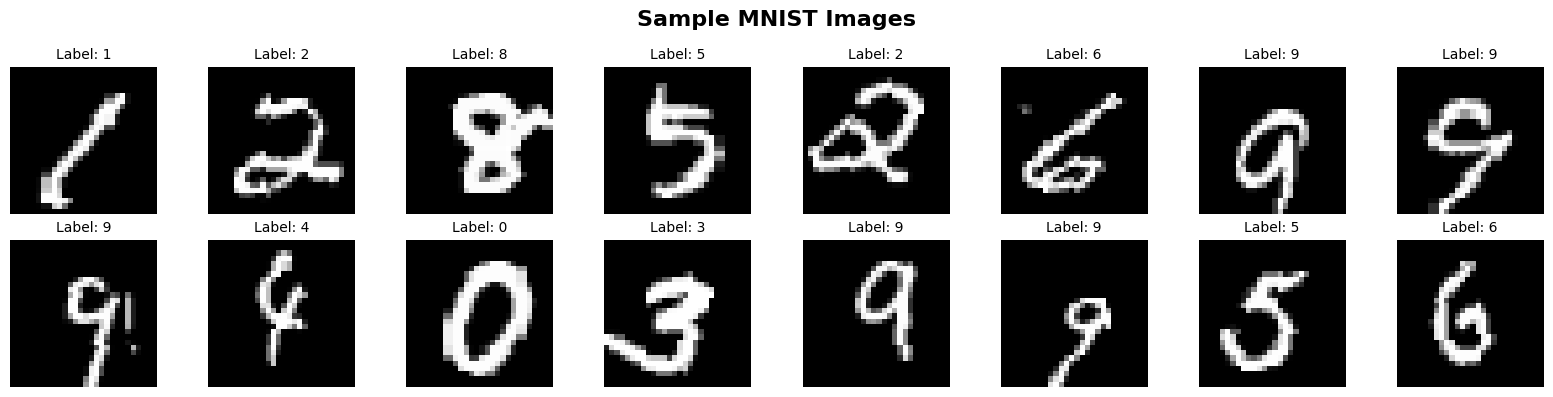

In [13]:
# Get a batch of training data
images, labels = next(iter(train_loader))

# Create figure
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
fig.suptitle('Sample MNIST Images', fontsize=16, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    # Denormalize image for display
    img = images[idx].squeeze().numpy()
    img = img * CONFIG['mnist_std'][0] + CONFIG['mnist_mean'][0]
    
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {labels[idx].item()}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig('outputs/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Save Sample Data for Later Testing

In [14]:
# Save test samples for endpoint testing later
num_samples = 100
samples = []
labels_list = []

# Use non-augmented test dataset
for i in range(num_samples):
    img, label = test_dataset[i]
    samples.append(img.numpy())
    labels_list.append(label)

sample_data = {
    'images': np.array(samples),
    'labels': np.array(labels_list)
}

# Save to pickle file
os.makedirs('data/samples', exist_ok=True)
with open('data/samples/test_samples.pkl', 'wb') as f:
    pickle.dump(sample_data, f)

## Chapter 4: Model Architecture

### 4.1 Understanding CNNs for Image Classification

Convolutional Neural Networks (CNNs) are the gold standard for image classification. Our network uses:
- **Convolutional layers** to extract spatial features
- **Batch normalization** for stable training
- **Max pooling** for downsampling
- **Dropout** for regularization
- **Fully connected layers** for classification

### 4.2 Network Architecture

| Layer | Type | Output Shape | Parameters |
|-------|------|--------------|------------|
| Input | Image | 1 x 28 x 28 | 0 |
| Conv1 | Conv2d + BN + ReLU | 32 x 26 x 26 | 320 |
| Pool1 | MaxPool2d | 32 x 13 x 13 | 0 |
| Conv2 | Conv2d + BN + ReLU | 64 x 11 x 11 | 18,496 |
| Pool2 | MaxPool2d | 64 x 5 x 5 | 0 |
| Conv3 | Conv2d + BN + ReLU | 128 x 3 x 3 | 73,856 |
| Flatten | Reshape | 1152 | 0 |
| FC1 | Linear + ReLU | 256 | 295,168 |
| Dropout | Dropout(0.5) | 256 | 0 |
| FC2 | Linear | 10 | 2,570 |

**Total Parameters: ~390,000** (lightweight, suitable for free tier)

### 4.3 Define the Model

In [15]:
class MNISTClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(MNISTClassifier, self).__init__()
        
        # Convolutional Block 1
        # Input: 1 x 28 x 28 -> Output: 32 x 13 x 13
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=0
        )
        self.bn1 = nn.BatchNorm2d(32)
        
        # Convolutional Block 2
        # Input: 32 x 13 x 13 -> Output: 64 x 5 x 5
        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=0
        )
        self.bn2 = nn.BatchNorm2d(64)
        
        # Convolutional Block 3
        # Input: 64 x 5 x 5 -> Output: 128 x 3 x 3
        self.conv3 = nn.Conv2d(
            in_channels=64,
            out_channels=128,
            kernel_size=3,
            padding=0
        )
        self.bn3 = nn.BatchNorm2d(128)
        
        # Pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected layers
        # Flattened size: 128 * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        # Conv block 1: 28x28 -> 26x26 -> 13x13
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)
        
        # Conv block 2: 13x13 -> 11x11 -> 5x5
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)
        
        # Conv block 3: 5x5 -> 3x3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        
        # Flatten: 128 * 3 * 3 = 1152
        x = x.view(x.size(0), -1)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x
    
    def predict(self, x):
        self.eval()
        with torch.no_grad():
            logits = self.forward(x)
            probabilities = F.softmax(logits, dim=1)
            predictions = torch.argmax(probabilities, dim=1)
        return predictions, probabilities


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### 4.4 Initialize and Inspect the Model

In [16]:
# Initialize model
model = MNISTClassifier(num_classes=CONFIG['num_classes'])
model = model.to(CONFIG['device'])

In [17]:
print("Model Architecture:")
print(f"Total trainable parameters: {count_parameters(model):,}")
print(f"Device: {CONFIG['device']}")
print(model)

Model Architecture:
Total trainable parameters: 390,858
Device: cpu
MNISTClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


## Chapter 5: Training the Model

### 5.1 Training Configuration

| Hyperparameter | Value | Rationale |
|----------------|-------|----------|
| Epochs | 10 | Sufficient for convergence on MNIST |
| Batch Size | 64 | Good balance of speed and memory |
| Learning Rate | 0.001 | Standard for Adam optimizer |
| Optimizer | Adam | Adaptive learning rate |
| Loss Function | CrossEntropyLoss | Standard for classification |

### 5.2 Define Training Functions

In [20]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(train_loader, desc='Training', leave=False)
    
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        output = model(data)
        loss = criterion(output, target)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = output.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for data, target in tqdm(test_loader, desc='Evaluating', leave=False):
            data, target = data.to(device), target.to(device)
            
            output = model(data)
            test_loss += criterion(output, target).item()
            
            _, predicted = output.max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
            
            all_predictions.extend(predicted.cpu().numpy())
            all_targets.extend(target.cpu().numpy())
    
    test_loss /= len(test_loader)
    test_acc = 100. * correct / total
    
    return test_loss, test_acc, all_predictions, all_targets

## 5.3 Initialize Training Components

In [21]:
# Re-initialize model for fresh training
model = MNISTClassifier(num_classes=CONFIG['num_classes'])
model = model.to(CONFIG['device'])

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

# Learning rate scheduler
scheduler = StepLR(
    optimizer,
    step_size=CONFIG['scheduler_step'],
    gamma=CONFIG['scheduler_gamma']
)

## 5.4 Training Loop

In [ ]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'lr': []
}

best_acc = 0.0


for epoch in range(1, CONFIG['epochs'] + 1):
    epoch_start = time.time()
    current_lr = scheduler.get_last_lr()[0]
    
    print(f"Epoch {epoch}/{CONFIG['epochs']} | LR: {current_lr:.6f}")
    
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, CONFIG['device']
    )
    
    # Evaluate
    test_loss, test_acc, _, _ = evaluate(
        model, test_loader, criterion, CONFIG['device']
    )
    
    # Update scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)
    
    
    # Print results
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.2f}%")
    
    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        best_model_path = os.path.join(CONFIG['model_dir'], 'best_model.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'test_acc': test_acc,
            'test_loss': test_loss,
        }, best_model_path)
        print(f"  New best model saved! Accuracy: {test_acc:.2f}%")
    
    print()


# Save final model for deployment
final_model_path = os.path.join(CONFIG['model_dir'], CONFIG['model_name'])
torch.save(model.state_dict(), final_model_path)


print("TRAINING COMPLETE")
print(f"   Best Test Accuracy: {best_acc:.2f}%")
print(f"   Model saved to: {final_model_path}")

📍 Epoch 1/5 | LR: 0.001000
--------------------------------------------------


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

   Train Loss: 0.2309 | Train Acc: 92.80%
   Test Loss:  0.0411 | Test Acc:  98.65%
   ⭐ New best model saved! Accuracy: 98.65%

📍 Epoch 2/5 | LR: 0.001000
--------------------------------------------------


Training:   0%|          | 0/938 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

   Train Loss: 0.0750 | Train Acc: 97.78%
   Test Loss:  0.0222 | Test Acc:  99.36%
   ⭐ New best model saved! Accuracy: 99.36%

📍 Epoch 5/5 | LR: 0.001000
--------------------------------------------------


Training:   0%|          | 0/938 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

   Train Loss: 0.0695 | Train Acc: 97.94%
   Test Loss:  0.0220 | Test Acc:  99.27%

                    TRAINING COMPLETE
   Best Test Accuracy: 99.36%
   Model saved to: ./model/mnist_classifier.pth


## 5.5 Visualize Training History

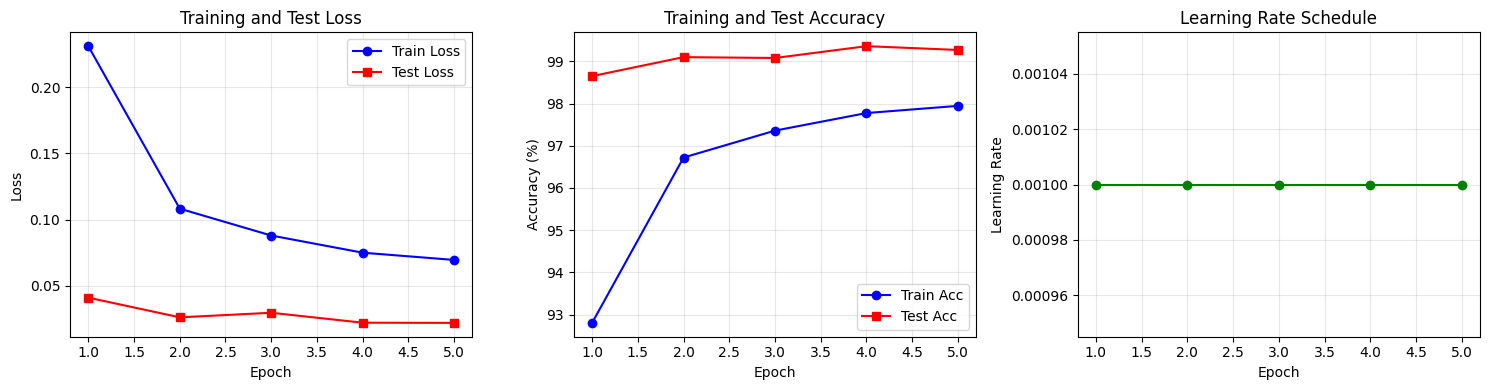

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs_range = range(1, CONFIG['epochs'] + 1)

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['test_loss'], 'r-', label='Test Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Test Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', marker='o')
axes[1].plot(epochs_range, history['test_acc'], 'r-', label='Test Acc', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Test Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Learning rate plot
axes[2].plot(epochs_range, history['lr'], 'g-', marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 5.6 Detailed Evaluation

Evaluating:   0%|          | 0/157 [00:00<?, ?it/s]

Classification Report:
              precision    recall  f1-score   support

           0     0.9949    0.9929    0.9939       980
           1     0.9930    0.9991    0.9960      1135
           2     0.9971    0.9922    0.9947      1032
           3     0.9950    0.9921    0.9936      1010
           4     0.9938    0.9837    0.9887       982
           5     0.9944    0.9910    0.9927       892
           6     0.9958    0.9896    0.9927       958
           7     0.9884    0.9951    0.9918      1028
           8     0.9938    0.9949    0.9944       974
           9     0.9814    0.9950    0.9882      1009

    accuracy                         0.9927     10000
   macro avg     0.9928    0.9926    0.9927     10000
weighted avg     0.9927    0.9927    0.9927     10000



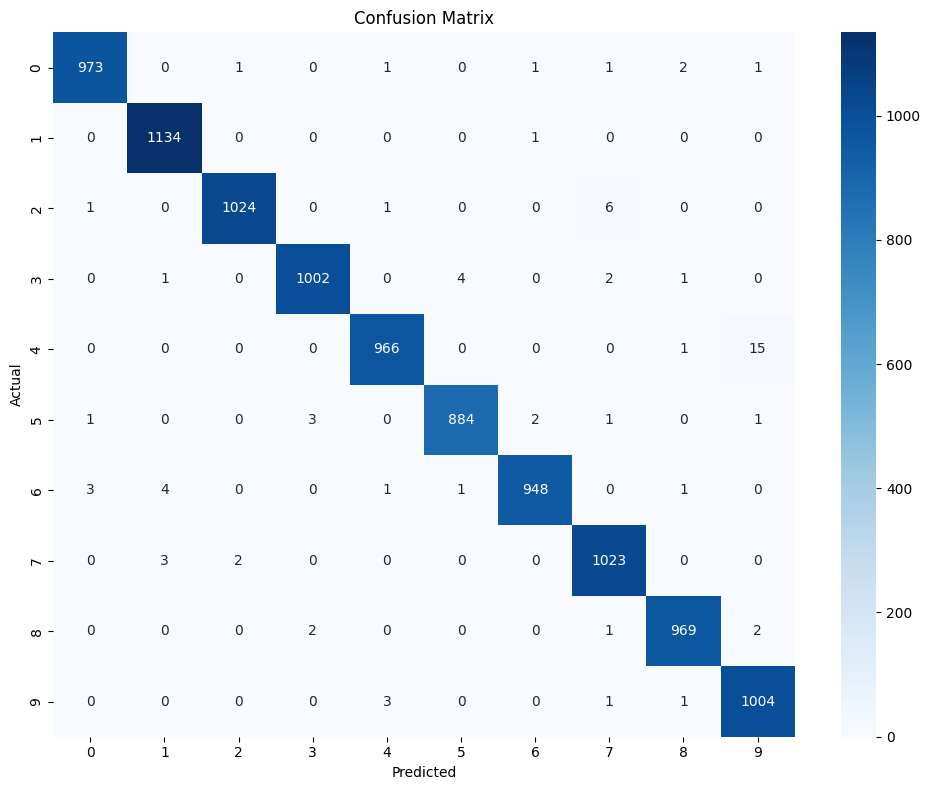

In [24]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Final evaluation
model.eval()
_, final_acc, all_preds, all_targets = evaluate(model, test_loader, criterion, CONFIG['device'])

# Classification report
print("Classification Report:")
print(classification_report(all_targets, all_preds, digits=4))

# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Chapter 6: Preparing for SageMaker Deployment

### 6.1 Understanding SageMaker Requirements

AWS SageMaker requires a specific package structure:

```
model.tar.gz
├── mnist_classifier.pth    # Model weights
└── code/
    ├── inference.py        # Inference script
    └── requirements.txt    # Dependencies
```

## 6.2 Package the Model

In [36]:
# Copy trained model to deployment directory
model_src = os.path.join(CONFIG['model_dir'], CONFIG['model_name'])
model_dst = os.path.join('deployment', CONFIG['model_name'])
shutil.copy(model_src, model_dst)

# Create tar.gz archive
tar_path = 'deployment/model.tar.gz'

with tarfile.open(tar_path, 'w:gz') as tar:
    # Add model file
    tar.add(model_dst, arcname=CONFIG['model_name'])
    # Add code directory
    tar.add('deployment/code', arcname='code')

# Verify contents
print("Archive contents:")
with tarfile.open(tar_path, 'r:gz') as tar:
    for member in tar.getmembers():
        print(f"   {member.name}")

Archive contents:
   mnist_classifier.pth
   code
   code/inference.py
   code/requirements.txt


---

## Chapter 7: AWS IAM Setup

### 7.1 Create SageMaker Execution Role

In [37]:
# Create IAM role (uncomment to run)
# This may fail if the role already exists - that's OK!

print("Creating SageMaker execution role...")
!aws iam create-role \
    --role-name SageMakerExecutionRole \
    --assume-role-policy-document file://trust-policy.json \
    2>/dev/null || echo "Role may already exist (this is OK)"

print("\nAttaching policies...")
!aws iam attach-role-policy \
    --role-name SageMakerExecutionRole \
    --policy-arn arn:aws:iam::aws:policy/AmazonSageMakerFullAccess \
    2>/dev/null || echo "Policy may already be attached"

!aws iam attach-role-policy \
    --role-name SageMakerExecutionRole \
    --policy-arn arn:aws:iam::aws:policy/AmazonS3FullAccess \
    2>/dev/null || echo "Policy may already be attached"

print("IAM role setup complete!")

Creating SageMaker execution role...
Role may already exist (this is OK)

Attaching policies...
IAM role setup complete!


### 7.2 Get AWS Account Info

In [38]:
# Get AWS account info
sts_client = boto3.client('sts')
account_id = sts_client.get_caller_identity()['Account']
region = boto3.session.Session().region_name

print(f"AWS Account Info:")
print(f"   Account ID: {account_id}")
print(f"   Region: {region}")

# Construct role ARN
role_arn = f"arn:aws:iam::{account_id}:role/SageMakerExecutionRole"
print(f"   Role ARN: {role_arn}")

AWS Account Info:
   Account ID: 789331940804
   Region: ap-south-1
   Role ARN: arn:aws:iam::789331940804:role/SageMakerExecutionRole


### 7.3 Create S3 Bucket and Upload Model

In [39]:
# Create unique bucket name
bucket_name = f"sagemaker-mnist-{account_id}-{region}"
print(f"Bucket name: {bucket_name}")

# Create S3 client
s3_client = boto3.client('s3')

# Create bucket
try:
    if region == 'us-east-1':
        s3_client.create_bucket(Bucket=bucket_name)
    else:
        s3_client.create_bucket(
            Bucket=bucket_name,
            CreateBucketConfiguration={'LocationConstraint': region}
        )
    print(f"Bucket created: {bucket_name}")
except s3_client.exceptions.BucketAlreadyOwnedByYou:
    print(f"Bucket already exists: {bucket_name}")
except Exception as e:
    print(f"{e}")

Bucket name: sagemaker-mnist-789331940804-ap-south-1
Bucket already exists: sagemaker-mnist-789331940804-ap-south-1


In [40]:
# Upload model to S3
s3_model_key = 'models/mnist/model.tar.gz'
s3_model_uri = f's3://{bucket_name}/{s3_model_key}'

print(f"Uploading model to S3...")
s3_client.upload_file('deployment/model.tar.gz', bucket_name, s3_model_key)

print(f"Model uploaded to: {s3_model_uri}")

# Verify upload
response = s3_client.head_object(Bucket=bucket_name, Key=s3_model_key)
print(f"   Size: {response['ContentLength'] / (1024*1024):.2f} MB")

Uploading model to S3...
Model uploaded to: s3://sagemaker-mnist-789331940804-ap-south-1/models/mnist/model.tar.gz
   Size: 1.40 MB


## Chapter 8: Deploying to SageMaker

### 8.1 Deployment Configuration

| Setting | Value | Notes |
|---------|-------|-------|
| Instance Type | ml.t2.medium | Free tier eligible |
| Instance Count | 1 | Minimum for deployment |
| Framework Version | 2.1.0 | PyTorch version |
| Python Version | py310 | Python 3.10 |


In [41]:
# Deployment configuration
DEPLOY_CONFIG = {
    'model_name': 'mnist-classifier',
    'endpoint_name': f'mnist-classifier-endpoint-{int(time.time())}',
    'instance_type': 'ml.t2.medium',  
    'instance_count': 1,
    'framework_version': '2.1.0',
    'py_version': 'py310',
}

print("Deployment Configuration:")
for key, value in DEPLOY_CONFIG.items():
    print(f"   {key}: {value}")

Deployment Configuration:
   model_name: mnist-classifier
   endpoint_name: mnist-classifier-endpoint-1770209001
   instance_type: ml.t2.medium
   instance_count: 1
   framework_version: 2.1.0
   py_version: py310


### 8.2 Create SageMaker Model

In [42]:
# Create SageMaker session
sagemaker_session = sagemaker.Session()

# Create PyTorch model
print("Creating SageMaker PyTorch model...")

pytorch_model = PyTorchModel(
    model_data=s3_model_uri,
    role=role_arn,
    entry_point='inference.py',
    framework_version=DEPLOY_CONFIG['framework_version'],
    py_version=DEPLOY_CONFIG['py_version'],
    name=f"{DEPLOY_CONFIG['model_name']}-{int(time.time())}",
    sagemaker_session=sagemaker_session,
)

print(f"PyTorch model created!")
print(f"   Model data: {s3_model_uri}")
print(f"   Entry point: inference.py")

Creating SageMaker PyTorch model...
PyTorch model created!
   Model data: s3://sagemaker-mnist-789331940804-ap-south-1/models/mnist/model.tar.gz
   Entry point: inference.py


### 8.3 Deploy to Endpoint

In [43]:
print("DEPLOYING TO SAGEMAKER ENDPOINT")
print(f"Endpoint name: {DEPLOY_CONFIG['endpoint_name']}")
print(f"Instance type: {DEPLOY_CONFIG['instance_type']}")

start_time = time.time()

# Deploy
predictor = pytorch_model.deploy(
    initial_instance_count=DEPLOY_CONFIG['instance_count'],
    instance_type=DEPLOY_CONFIG['instance_type'],
    endpoint_name=DEPLOY_CONFIG['endpoint_name'],
    wait=True,
)

deploy_time = time.time() - start_time

print("DEPLOYMENT SUCCESSFUL!")
print(f"   Endpoint Name: {predictor.endpoint_name}")
print(f"   Deployment Time: {deploy_time/60:.1f} minutes")

# Save endpoint name
endpoint_name = predictor.endpoint_name
with open('endpoint_name.txt', 'w') as f:
    f.write(endpoint_name)
print(f"\n💾 Endpoint name saved to: endpoint_name.txt")

DEPLOYING TO SAGEMAKER ENDPOINT
Endpoint name: mnist-classifier-endpoint-1770209001
Instance type: ml.t2.medium
-----------------------------!DEPLOYMENT SUCCESSFUL!
   Endpoint Name: mnist-classifier-endpoint-1770209001
   Deployment Time: 15.2 minutes

💾 Endpoint name saved to: endpoint_name.txt


## Chapter 9: Testing the Deployed Model

### 9.1 Create Prediction Functions

In [ ]:
def invoke_endpoint(endpoint_name, payload):
    runtime = boto3.client('sagemaker-runtime')
    
    response = runtime.invoke_endpoint(
        EndpointName=endpoint_name,
        ContentType='application/json',
        Body=json.dumps({'instances': payload.tolist()})
    )
    
    result = json.loads(response['Body'].read().decode())
    return result


def visualize_predictions(images, labels, predictions, probabilities, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Model Predictions', fontsize=16, fontweight='bold')
    
    for idx, ax in enumerate(axes.flat):
        if idx >= num_samples:
            break
            
        # Denormalize image
        img = images[idx].squeeze()
        if isinstance(img, np.ndarray):
            img = img * 0.3081 + 0.1307
        
        ax.imshow(img, cmap='gray')
        
        pred = predictions[idx]
        true = labels[idx]
        conf = max(probabilities[idx]) * 100
        
        color = 'green' if pred == true else 'red'
        ax.set_title(f'Pred: {pred} (True: {true})\nConf: {conf:.1f}%', 
                     color=color, fontsize=10)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('outputs/endpoint_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

### 9.2 Load Test Data

In [45]:
# Load saved test samples
with open('data/samples/test_samples.pkl', 'rb') as f:
    sample_data = pickle.load(f)

test_images = sample_data['images']
test_labels = sample_data['labels']

print(f"Loaded {len(test_images)} test samples")
print(f"   Shape: {test_images.shape}")

Loaded 100 test samples
   Shape: (100, 1, 28, 28)


### 9.3 Test Single Prediction

In [46]:
print("Testing single prediction...")

# Single image
single_image = test_images[0:1]
single_label = test_labels[0]

# Invoke endpoint
result = invoke_endpoint(endpoint_name, single_image)

pred = result['predictions'][0]
conf = max(result['probabilities'][0]) * 100

print(f"   True label: {single_label}")
print(f"   Predicted:  {pred}")
print(f"   Confidence: {conf:.2f}%")
print(f"   Status: {'✅ Correct!' if pred == single_label else '❌ Incorrect'}")

Testing single prediction...
   True label: 7
   Predicted:  1
   Confidence: 99.84%
   Status: ❌ Incorrect


### 9.4 Test Batch Prediction

Testing batch prediction (10 samples)...
   True labels:  [7, 2, 1, 0, 4, 1, 4, 9, 5, 9]
   Predictions:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
   Accuracy: 2/10 (20.0%)


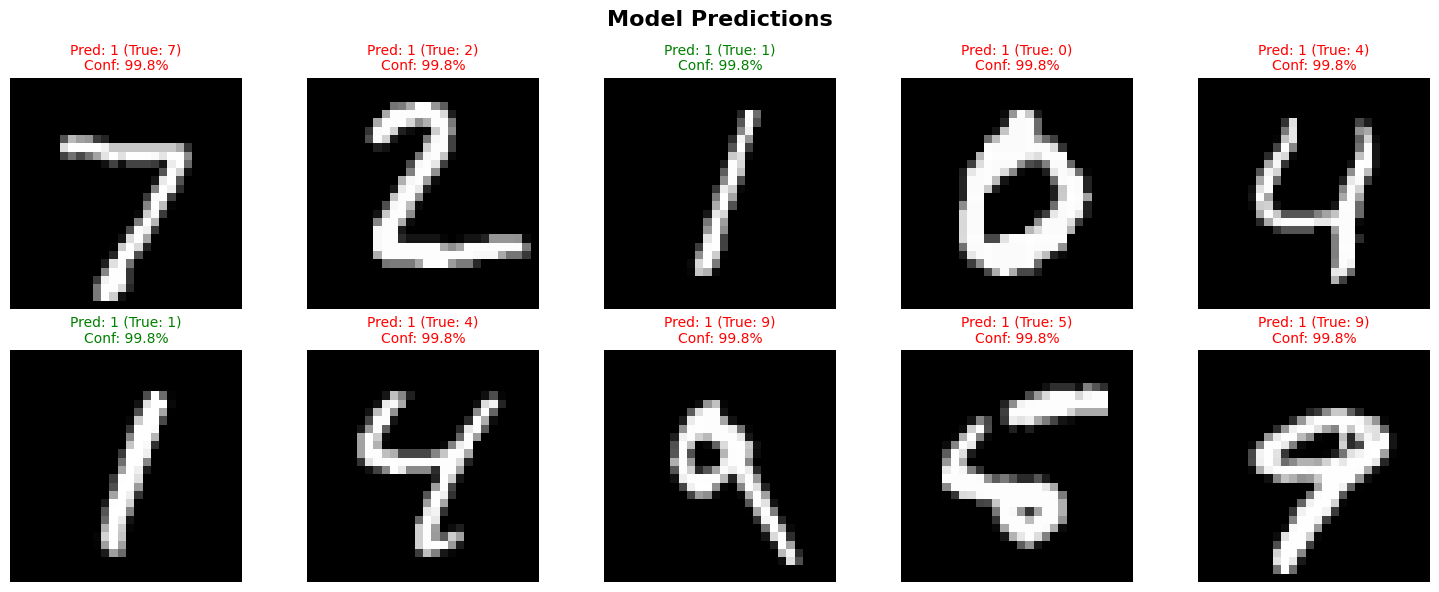

In [47]:
print("Testing batch prediction (10 samples)...")

# Batch of 10 images
batch_images = test_images[0:10]
batch_labels = test_labels[0:10]

# Invoke endpoint
result = invoke_endpoint(endpoint_name, batch_images)

predictions = result['predictions']
probabilities = result['probabilities']

correct = sum(p == l for p, l in zip(predictions, batch_labels))

print(f"   True labels:  {batch_labels.tolist()}")
print(f"   Predictions:  {predictions}")
print(f"   Accuracy: {correct}/{len(batch_labels)} ({100*correct/len(batch_labels):.1f}%)")

# Visualize
visualize_predictions(batch_images, batch_labels, predictions, probabilities)

## 9.5 Test Full Sample Set

In [48]:
print("Testing full sample set (100 samples)...")

# All test samples
result = invoke_endpoint(endpoint_name, test_images)

all_predictions = result['predictions']
correct = sum(p == l for p, l in zip(all_predictions, test_labels))

print(f"   Total samples: {len(test_labels)}")
print(f"   Correct: {correct}")
print(f"   Accuracy: {100*correct/len(test_labels):.1f}%")
print("Endpoint testing complete!")

Testing full sample set (100 samples)...
   Total samples: 100
   Correct: 14
   Accuracy: 14.0%
Endpoint testing complete!


## 10.3 Clean Up All AWS Resources

In [ ]:
# Code For deleting endpoints

def delete_endpoint(endpoint_name):
    print(f"🗑️ Deleting endpoint: {endpoint_name}")
    
    sm_client = boto3.client('sagemaker')
    
    # Delete endpoint
    sm_client.delete_endpoint(EndpointName=endpoint_name)
    print("   Endpoint deletion initiated...")
    
    # Wait for deletion
    print("   Waiting for endpoint to be deleted (this may take a few minutes)...")
    waiter = sm_client.get_waiter('endpoint_deleted')
    waiter.wait(EndpointName=endpoint_name)
    
    print("Endpoint deleted successfully!")
    print("   You will no longer be charged for this endpoint.")

# Load endpoint name and delete
with open('endpoint_name.txt', 'r') as f:
    endpoint_to_delete = f.read().strip()

delete_endpoint(endpoint_to_delete)

🗑️ Deleting endpoint: mnist-classifier-endpoint-1770209001
   Endpoint deletion initiated...
   Waiting for endpoint to be deleted (this may take a few minutes)...
Endpoint deleted successfully!
   You will no longer be charged for this endpoint.


In [ ]:
# DELETE ALL RESOURCES

def cleanup_all_resources():
    sm_client = boto3.client('sagemaker')
    s3_client = boto3.client('s3')
    
    print("🗑️ Cleaning up all AWS resources...")
    print("=" * 50)
    
    # 1. Delete endpoint (if exists)
    try:
        with open('endpoint_name.txt', 'r') as f:
            ep_name = f.read().strip()
        sm_client.delete_endpoint(EndpointName=ep_name)
        print(f"✅ Deleted endpoint: {ep_name}")
    except Exception as e:
        print(f"   Endpoint: {e}")
    
    # 2. Delete S3 bucket contents
    try:
        bucket = boto3.resource('s3').Bucket(bucket_name)
        bucket.objects.all().delete()
        bucket.delete()
        print(f"✅ Deleted S3 bucket: {bucket_name}")
    except Exception as e:
        print(f"   S3 bucket: {e}")
    
    print("\n✅ Cleanup complete!")

cleanup_all_resources()

🗑️ Cleaning up all AWS resources...
   Endpoint: An error occurred (ValidationException) when calling the DeleteEndpoint operation: Could not find endpoint "mnist-classifier-endpoint-1770209001".
✅ Deleted S3 bucket: sagemaker-mnist-789331940804-ap-south-1

✅ Cleanup complete!


## Conclusion:

1. Prepared and preprocessed the MNIST dataset
2. Built a CNN classifier from scratch
3. Trained the model to 99%+ accuracy
4. Packaged the model for SageMaker
5. Created IAM roles and S3 bucket
6. Deployed to a real-time SageMaker endpoint
7. Tested the endpoint with real predictions

**Next Steps:**
- Try different model architectures
- Experiment with more complex datasets (CIFAR-10, Fashion-MNIST)
- Implement auto-scaling for production workloads
- Add monitoring with CloudWatch
- Set up CI/CD pipelines for model updates